In [1]:
import os
import json
import datasets

sft_data_dir = '/home/jadeleiyu/projects/mbrl_agent/world_model/sft_data'
n_jobs = 8

wm_cot_data = []
for job_id in range(n_jobs):
    try:
        with open(os.path.join(sft_data_dir, f"wm_cot_gen_outputs_{job_id}.json"), 'r') as f:
            wm_cot_data_i = json.load(f)
        wm_cot_data += wm_cot_data_i
    except FileNotFoundError as e:
        pass




/home/jadeleiyu/miniforge3/envs/mbrl_agent/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
len(wm_cot_data)

58056

In [3]:
import random
random.shuffle(wm_cot_data)

In [4]:
SYS_PROMPT_WM_SFT = """You are an intelligent agent that predicts next state from given current action in a web environment, with your own logical reasoning. 

Here's the information you'll have:
The user's objective: This is the task you're trying to complete.
The current web page's accessibility tree: This is a simplified representation of the webpage, providing key information.
The current web page's URL: This is the page you're currently navigating.
The previous action: This is the action you just performed in the previous step. It may be helpful to track your progress. 
The current action: This is the current action that you performed to achieve the user's objective in the current web page's accessibility tree.
The format of previous actions can fall into several categories:
Page Operation Actions:

```click [id]```: This action clicks on an element with a specific id on the webpage.
```type [id] [content]```: Use this to type the content into the field with id. By default, the 'Enter' key is pressed after typing unless press_enter_after is set to 0, i.e., ```type [id] [content] [0]```.
```hover [id]```: Hover over an element with id.
```press [key_comb]```: Simulates the pressing of a key combination on the keyboard (e.g., Ctrl+v).
```scroll [down]``` or ```scroll [up]```: Scroll the page up or down.

Tab Management Actions:
```new_tab```: Open a new, empty browser tab.
```tab_focus [tab_index]```: Switch the browser's focus to a specific tab using its index.
```close_tab```: Close the currently active tab.

URL Navigation Actions:
```goto [url]```: Navigate to a specific URL.
```go_back```: Navigate to the previously viewed page.
```go_forward```: Navigate to the next page (if a previous 'go_back' action was performed)

Completion Action:
```stop [answer]```: Done when you believe the task is complete.
"""


USER_PROMPT_WM_SFT = """User objective: {usr_obj}
Current web page accessibility tree: {curr_acc_tree}
Current web page URL: {curr_url}
Previous action: {prev_action}
Current action: {curr_action}
"""

# ASSISTANT_PROMPT_WM_SFT = """The expected next web page accessibility tree is:\n\n\n"""


In [5]:
from transformers import AutoTokenizer
from matplotlib import pyplot as plt
from tqdm import tqdm

tokenizer = AutoTokenizer.from_pretrained("unsloth/gpt-oss-120b-BF16", trust_remote_code=True)
wm_sft_data = []

for i in tqdm(range(len(wm_cot_data))):
    example = wm_cot_data[i]
    messages = [
        {'role':'system', 'content': SYS_PROMPT_WM_SFT},
        {'role': 'user', 'content': USER_PROMPT_WM_SFT.format(
            usr_obj=example['objective'],
            curr_acc_tree=example['current_observation'],
            curr_url=example['current_url'],
            prev_action=example['previous_action'],
            curr_action=example['current_action']
        )},
        {
            'role': 'assistant', 
            'content': example['wm_cot']
        }
    ]
    wm_sft_data.append({
        'source_dataset': example['source_dataset'],
        'messages': messages,
        'next_observation': example["next_observation"]
    })



100%|██████████████████████████████████████████████████████████████████████████████████████| 58056/58056 [00:02<00:00, 27197.36it/s]


In [6]:
from datasets import Dataset

wm_sft_data = Dataset.from_list(wm_sft_data)
wm_sft_data.push_to_hub("jadeleiyu/WM-sft_gpt-oss")


Creating parquet from Arrow format: 100%|███████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  8.99ba/s]
Processing Files (0 / 0)                : |                                                            |  0.00B /  0.00B            

Processing Files (0 / 1)                :   5%|██▋                                                     | 7.38MB /  154MB, 37.0MB/s  
Processing Files (0 / 1)                :  42%|███████████████████████▍                                | 64.3MB /  154MB,  161MB/s  
Processing Files (0 / 1)                :  94%|████████████████████████████████████████████████████▍   |  144MB /  154MB,  240MB/s  
Processing Files (0 / 1)                :  99%|███████████████████████████████████████████████████████▌|  153MB /  154MB,  191MB/s  
Processing Files (0 / 1)                : 100%|███████████████████████████████████████████████████████▊|  153MB /  154MB,  153MB/s  

Processing Files (1 / 1)                : 100%|████████████████████

CommitInfo(commit_url='https://huggingface.co/datasets/jadeleiyu/WM-sft_gpt-oss/commit/12acd2e392acf6ad4dff2fa4657e96f9f2ba28b0', commit_message='Upload dataset', commit_description='', oid='12acd2e392acf6ad4dff2fa4657e96f9f2ba28b0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/jadeleiyu/WM-sft_gpt-oss', endpoint='https://huggingface.co', repo_type='dataset', repo_id='jadeleiyu/WM-sft_gpt-oss'), pr_revision=None, pr_num=None)

In [9]:
# avg input length

input_lens = []
for i in tqdm(range(len(wm_sft_data))):
    messages = wm_sft_data[i]['messages']
    tokenized_input_i = tokenizer.apply_chat_template(messages)
    input_lens.append(len(tokenized_input_i))

100%|████████████████████████████████████████████████████████████████████████████████████████| 36285/36285 [05:48<00:00, 104.05it/s]


(array([2.050e+02, 1.860e+02, 5.200e+02, 1.560e+03, 1.420e+03, 1.164e+03,
        1.057e+03, 6.630e+02, 4.460e+02, 4.150e+02, 3.810e+02, 3.950e+02,
        5.000e+02, 5.250e+02, 7.990e+02, 8.390e+02, 1.075e+03, 1.018e+03,
        7.340e+02, 5.820e+02, 3.730e+02, 5.940e+02, 8.990e+02, 8.640e+02,
        9.130e+02, 6.330e+02, 3.630e+02, 2.920e+02, 2.260e+02, 2.150e+02,
        1.710e+02, 2.090e+02, 2.020e+02, 2.310e+02, 2.210e+02, 2.630e+02,
        2.390e+02, 3.220e+02, 2.770e+02, 2.270e+02, 1.810e+02, 2.130e+02,
        1.940e+02, 1.980e+02, 1.840e+02, 1.200e+02, 9.900e+01, 1.350e+02,
        1.200e+02, 1.270e+02, 2.610e+02, 8.640e+02, 2.549e+03, 2.175e+03,
        1.630e+03, 1.215e+03, 6.420e+02, 2.730e+02, 1.220e+02, 9.900e+01,
        8.100e+01, 5.400e+01, 6.300e+01, 5.400e+01, 7.200e+01, 7.200e+01,
        5.200e+01, 5.000e+01, 3.500e+01, 4.000e+01, 3.300e+01, 3.600e+01,
        2.500e+01, 3.000e+01, 3.400e+01, 2.200e+01, 2.500e+01, 1.400e+01,
        2.600e+01, 2.600e+01, 4.700e+0

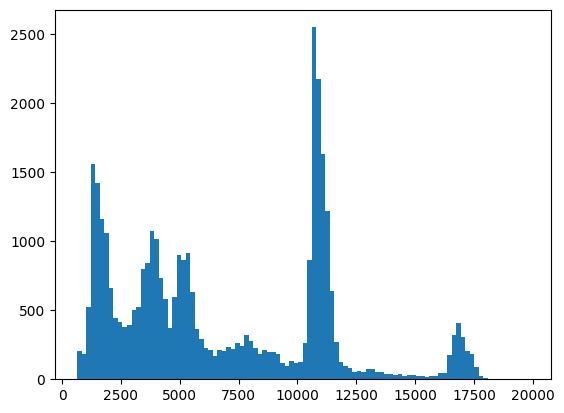

In [10]:
plt.hist(input_lens, bins=100)

In [7]:
wm_sft_data[0]

{'source_dataset': 'stanfordnlp/nnetnav-live',
 'messages': [{'content': "You are an intelligent agent that predicts next state from given current action in a web environment, with your own logical reasoning. \n\nHere's the information you'll have:\nThe user's objective: This is the task you're trying to complete.\nThe current web page's accessibility tree: This is a simplified representation of the webpage, providing key information.\nThe current web page's URL: This is the page you're currently navigating.\nThe previous action: This is the action you just performed in the previous step. It may be helpful to track your progress. \nThe current action: This is the current action that you performed to achieve the user's objective in the current web page's accessibility tree.\nThe format of previous actions can fall into several categories:\nPage Operation Actions:\n\n```click [id]```: This action clicks on an element with a specific id on the webpage.\n```type [id] [content]```: Use this

In [16]:
print(wm_sft_data[1489]['messages'][2]['content'])

**[Rationale]**  
The user clicked the **Issues** link in the project navigation sidebar while on the Pipelines page. This navigation causes the entire main content area to be replaced: the Pipelines view (filter textbox, “Show Pipeline ID” button, etc.) is removed and the Issues view is loaded. Consequently, the page title, breadcrumb trail, selected sidebar item, and the set of controls in the `<main>` region all change. Most of the static parts of the layout (header links, global search box, sidebar collapse button, etc.) remain the same, so only the altered nodes need to be described.

**[Web state changes]**  
- **RootWebArea title** changes from `'Pipelines · CellularPrivacy / Android-IMSI-Catcher-Detector · GitLab'` to `'Issues · CellularPrivacy / Android-IMSI-Catcher-Detector · GitLab'`.  
- **Breadcrumbs navigation** (`[5428]` → `[7024]`) now ends with link `'Issues'` (`[7420]`) instead of `'Pipelines'` (`[5840]`).  
- **Project navigation sidebar** (`[5414]` → `[7011]`):  
  